# Analysis for Cardiomyocyte Differentiation figure
This processes the already qc-ed & aggregated measurements for the Cardiomyocyte Differentiation figure in the paper.

In [1]:
import ngio
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [2]:
local_plate_url = "/Users/joel/Documents/TestDatasets/23well_benchmark/20200812-CardiomyocyteDifferentiation14-Cycle1_mip.zarr"
local_plate = ngio.open_ome_zarr_plate(local_plate_url)

In [3]:
df = local_plate.get_table("nuclei_measurements_qced").dataframe

In [4]:
df

,nuclei_filtered_Morphology_area,nuclei_filtered_Morphology_centroid-0,nuclei_filtered_Morphology_centroid-1,nuclei_filtered_Morphology_well_centroid-0,nuclei_filtered_Morphology_well_centroid-1,nuclei_filtered_Morphology_bbox_area,nuclei_filtered_Morphology_bbox-0,nuclei_filtered_Morphology_bbox-1,nuclei_filtered_Morphology_bbox-2,nuclei_filtered_Morphology_bbox-3,...,nuclei_filtered_Population_mean_distance_neighbours_radius_400,nuclei_filtered_Population_n_neighbours_radius_500,nuclei_filtered_Population_mean_distance_neighbours_radius_500,well_name,ROI,nanog_classifier,Sox17_classifier,NKX25_classifier,TroponinT_classifier,differentiation_day
label,,,,,,,,,,,,,,,,,,,,,
255,1903.0,92.464005,647.835022,92.464005,16007.834961,2958.0,70.0,615.0,121.0,673.0,...,240.234253,69.0,306.196106,B09,FOV_7,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,5
256,5027.0,116.085739,1196.467529,116.085739,16556.466797,8544.0,70.0,1149.0,159.0,1245.0,...,262.938599,57.0,335.310944,B09,FOV_7,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,5
257,5443.0,115.766121,880.044617,115.766121,11120.044922,7209.0,71.0,838.0,160.0,919.0,...,237.428467,38.0,305.473389,B09,FOV_5,nanog_negative,Sox17_positive,NKX25_negative,TroponinT_negative,5
258,1885.0,88.706100,2075.311523,88.706100,12315.311523,3060.0,71.0,2031.0,107.0,2116.0,...,231.332306,36.0,308.513672,B09,FOV_5,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,5
260,3257.0,109.134483,793.915588,109.134483,5913.915527,4422.0,76.0,761.0,142.0,828.0,...,259.891663,43.0,333.262085,B09,FOV_3,nanog_negative,Sox17_positive,NKX25_negative,TroponinT_negative,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73863,2531.0,2050.525391,984.713562,19330.525391,8664.713867,3074.0,2025.0,956.0,2078.0,1014.0,...,250.595825,113.0,319.164124,G10,FOV_68,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_positive,6
73865,3891.0,2052.596680,1219.142334,19332.597656,14019.142578,5900.0,2025.0,1165.0,2084.0,1265.0,...,264.738525,123.0,324.402985,G10,FOV_70,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,6
73867,3534.0,2054.503662,152.179688,19334.503906,7832.179688,4920.0,2026.0,110.0,2086.0,192.0,...,213.656281,64.0,284.033661,G10,FOV_68,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_negative,6


In [5]:
# Clean up categoricals
classifier_cols = [
    "nanog_classifier", "Sox17_classifier",
    "NKX25_classifier", "TroponinT_classifier",
]
for classifier_col in classifier_cols:
    df[classifier_col] = (
        df[classifier_col]
        .cat.remove_unused_categories()
    )

# Helper functions

In [6]:
def shuffled_view(df_plot, seed=0):
    idx = np.random.default_rng(seed).permutation(len(df_plot))
    return df_plot.iloc[idx]

def savefig_both(outbase, dpi=300):
    """
    Save current Matplotlib figure as both PDF and PNG.
    outbase: path without suffix, e.g. "figs/umap_day"
    """
    outbase = Path(outbase)
    outbase.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(outbase.with_suffix(".pdf"), dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase.with_suffix(".png"), dpi=dpi, bbox_inches="tight")


def umap_continuous_figure(df_plot, value_col, outbase=None, title=None,
                           s=2, alpha=0.8, cmap="viridis",
                           vmin=None, vmax=None, log_color=False):
    x = df_plot["UMAP1"].to_numpy()
    y = df_plot["UMAP2"].to_numpy()
    v = df_plot[value_col].to_numpy()

    if log_color:
        v = np.log1p(v)

    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(
        x, y, c=v, s=s, alpha=alpha, linewidths=0,
        cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True
    )

    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_title(title or value_col)

    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(value_col + (" (log1p)" if log_color else ""))

    xlim = (df_plot["UMAP1"].min(), df_plot["UMAP1"].max())
    ylim = (df_plot["UMAP2"].min(), df_plot["UMAP2"].max())
    # then in each plot:
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    if outbase:
        savefig_both(outbase)
    return fig, ax


def umap_categorical_figure(
    df_plot,
    cat_col,
    outbase=None,
    title=None,
    s=2,
    alpha=0.8,
    max_categories=20,
    color_map=None,
    default_color="lightgray",
):
    """
    UMAP scatter with explicit category->color mapping.

    color_map: dict {category_label: color}
               if None, a default gray/green binary map is used
    """

    # ---- Default explicit colormap (binary-friendly)
    if color_map is None:
        color_map = {
            "nanog_negative": "lightgray",
            "nanog_positive": "#1b9e77",
            "Sox17_negative": "lightgray",
            "Sox17_positive": "#1b9e77",
            "NKX25_negative": "lightgray",
            "NKX25_positive": "#1b9e77",
            "TroponinT_negative": "lightgray",
            "TroponinT_positive": "#1b9e77",
        }

    # Ensure categorical and drop unused categories
    cats = (
        df_plot[cat_col]
        .astype("category")
        .cat.remove_unused_categories()
    )

    # Optional collapse if too many categories
    if cats.nunique() > max_categories:
        top = cats.value_counts().index[:max_categories]
        cats = cats.where(cats.isin(top), other="Other").astype("category")

    # Map categories -> colors (per-point!)
    colors = cats.map(color_map).fillna(default_color)

    # ---- Plot
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(
        df_plot["UMAP1"],
        df_plot["UMAP2"],
        c=colors,
        s=s,
        alpha=alpha,
        linewidths=0,
        rasterized=True,
    )

    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_title(title or cat_col)

    # ---- Legend (only categories that actually appear)
    legend_handles = []
    for cat in cats.cat.categories:
        col = color_map.get(cat, default_color)
        legend_handles.append(
            plt.Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                color=col,
                label=str(cat),
                markersize=6,
            )
        )

    ax.legend(
        handles=legend_handles,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        title=cat_col,
    )

    # ---- Axes polish
    ax.set_xlim(df_plot["UMAP1"].min(), df_plot["UMAP1"].max())
    ax.set_ylim(df_plot["UMAP2"].min(), df_plot["UMAP2"].max())
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    if outbase:
        savefig_both(outbase)
    return fig, ax

# UMAP embedding

In [7]:
exclude_cols = [
    "well_name", "ROI",
    "nanog_classifier", "Sox17_classifier",
    "NKX25_classifier", "TroponinT_classifier",
    "differentiation_day",
]

X_scaled = StandardScaler().fit_transform(df.drop(columns=exclude_cols))

In [8]:
n_neighbors = 30  # test 10 - 100
min_dist = 0.05 # test 0.01 - 0.3
random_state=42

In [9]:
pca = PCA(n_components=50, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)

In [10]:
reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=2,
    metric="euclidean",
    random_state=random_state,
)
embedding = reducer.fit_transform(X_pca)

/Users/joel/Documents/Code/fractal-paper-2026/.pixi/envs/default/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
python(10534) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [12]:
df["UMAP1"] = embedding[:, 0]
df["UMAP2"] = embedding[:, 1]

In [13]:
# Optionally serialise the table with umap embeddings for easier reloading
from ngio.tables import FeatureTable
umap_ngio_table = FeatureTable(
    table_data=df,
    reference_label="nuclei_filtered",
)

local_plate_url = "/Users/joel/Documents/TestDatasets/23well_benchmark/20200812-CardiomyocyteDifferentiation14-Cycle1_mip.zarr"
local_plate = ngio.open_ome_zarr_plate(local_plate_url)
local_plate.add_table(
    name="nuclei_measurements_umaps",
    table=umap_ngio_table,
    backend="parquet",
    overwrite=True,
)

In [ ]:
# Optionally reload the table from disk
# local_plate_url = "/Users/joel/Documents/TestDatasets/23well_benchmark/20200812-CardiomyocyteDifferentiation14-Cycle1_mip.zarr"
# local_plate = ngio.open_ome_zarr_plate(local_plate_url)
# df = local_plate.get_table("nuclei_measurements_umaps").dataframe

In [14]:
df = shuffled_view(df, seed=random_state)

# Plots

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'UMAP colored by differentiation day'}, xlabel='UMAP1', ylabel='UMAP2'>)

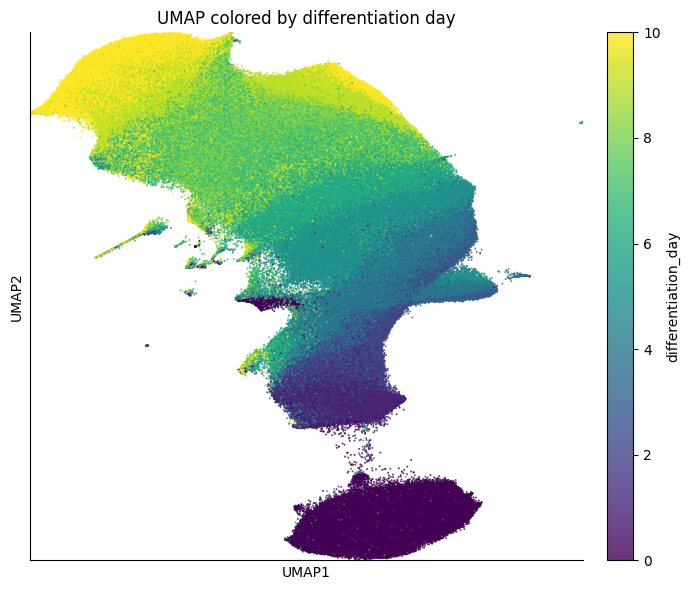

In [15]:
umap_continuous_figure(df, "differentiation_day",
                       outbase="figs/umap_day_viridis",
                       title="UMAP colored by differentiation day",
                       cmap="viridis")

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'TroponinT_classifier'}, xlabel='UMAP1', ylabel='UMAP2'>)

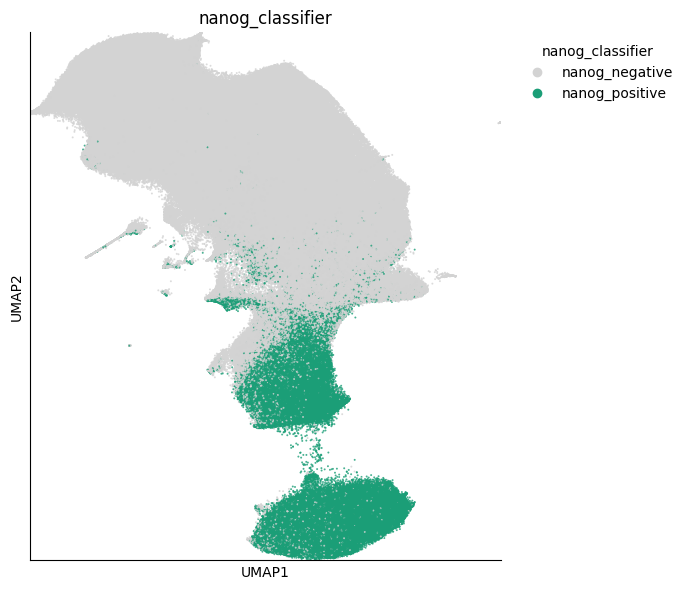

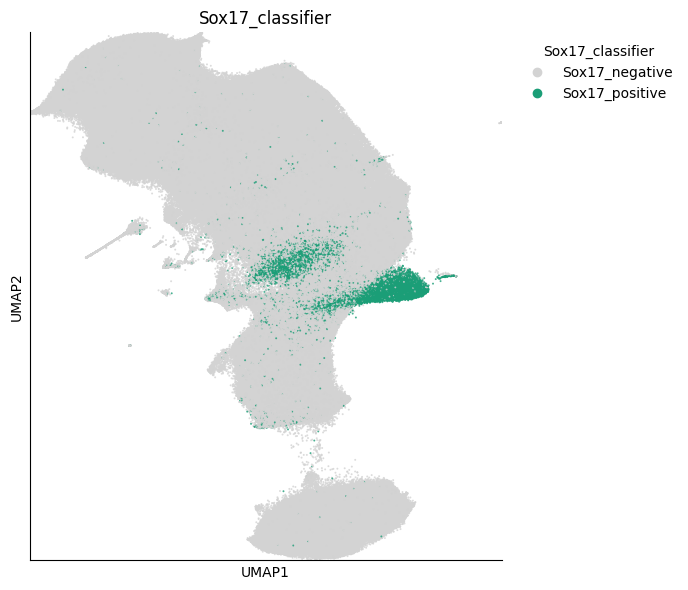

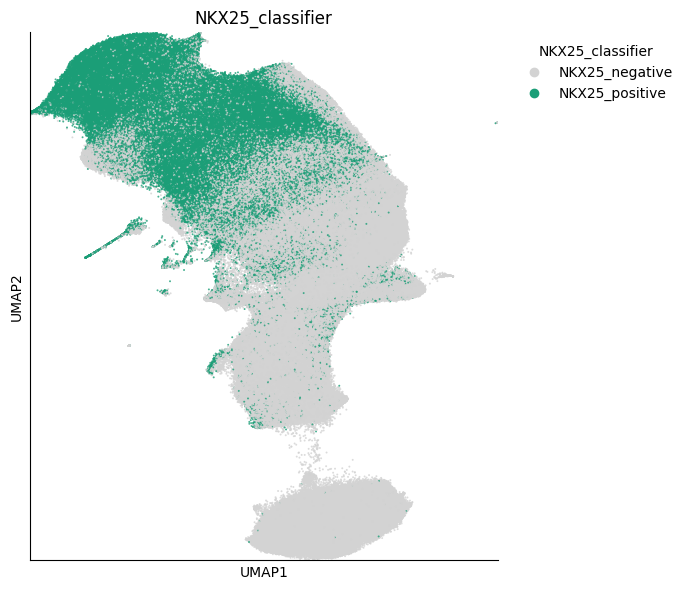

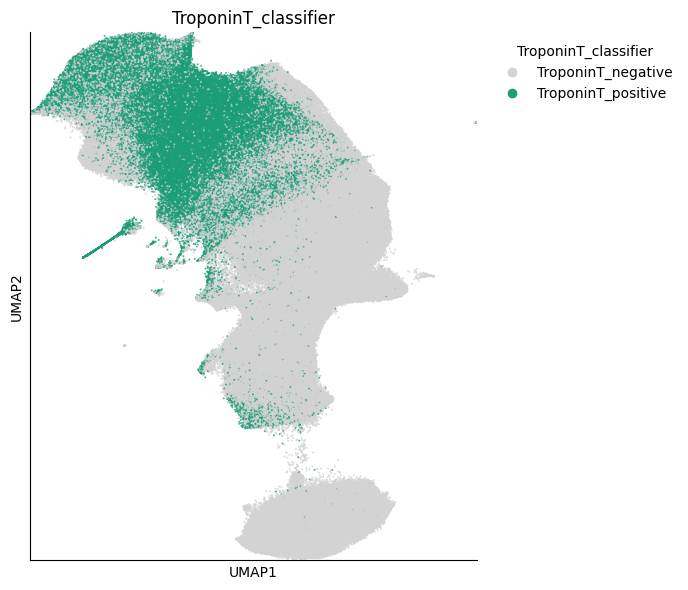

In [16]:
umap_categorical_figure(df, "nanog_classifier", outbase="figs/umap_nanog")
umap_categorical_figure(df, "Sox17_classifier", outbase="figs/umap_sox17")
umap_categorical_figure(df, "NKX25_classifier", outbase="figs/umap_nkx25")
umap_categorical_figure(df, "TroponinT_classifier", outbase="figs/umap_troponinT")

In [20]:
df

,nuclei_filtered_Morphology_area,nuclei_filtered_Morphology_centroid-0,nuclei_filtered_Morphology_centroid-1,nuclei_filtered_Morphology_well_centroid-0,nuclei_filtered_Morphology_well_centroid-1,nuclei_filtered_Morphology_bbox_area,nuclei_filtered_Morphology_bbox-0,nuclei_filtered_Morphology_bbox-1,nuclei_filtered_Morphology_bbox-2,nuclei_filtered_Morphology_bbox-3,...,nuclei_filtered_Population_mean_distance_neighbours_radius_500,well_name,ROI,nanog_classifier,Sox17_classifier,NKX25_classifier,TroponinT_classifier,differentiation_day,UMAP1,UMAP2
label,,,,,,,,,,,,,,,,,,,,,
214,6109.0,87.627602,1664.032715,87.627602,9344.033203,8475.0,50.0,1613.0,125.0,1726.0,...,302.699951,B09,FOV_4,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,5,11.081262,5.855969
215,4718.0,92.093262,165.185242,92.093262,165.185242,6162.0,51.0,126.0,130.0,204.0,...,309.615540,B09,FOV_1,nanog_negative,Sox17_positive,NKX25_negative,TroponinT_negative,5,9.440886,3.814721
216,4599.0,91.097412,1477.827148,91.097412,6597.827148,5920.0,51.0,1441.0,131.0,1515.0,...,292.548187,B09,FOV_3,nanog_negative,Sox17_positive,NKX25_negative,TroponinT_negative,5,9.271763,3.708536
217,8068.0,101.037308,431.152832,101.037308,2991.152832,9797.0,52.0,381.0,149.0,482.0,...,358.872559,B09,FOV_2,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,5,13.033437,6.257469
219,3333.0,88.151215,1583.671509,88.151215,14383.671875,4599.0,52.0,1552.0,125.0,1615.0,...,310.089539,B09,FOV_6,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_positive,5,11.668609,1.983851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73957,3611.0,2074.994385,710.316284,19354.994141,18630.316406,4900.0,2051.0,660.0,2100.0,760.0,...,290.618256,G10,FOV_72,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,6,11.525618,7.090116
73964,2288.0,2075.985107,260.677002,19355.984375,10500.676758,3283.0,2054.0,229.0,2103.0,296.0,...,282.861328,G10,FOV_69,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_negative,6,9.575070,7.088614
73970,2258.0,2083.329590,184.254211,19363.330078,10424.253906,3213.0,2056.0,150.0,2107.0,213.0,...,285.304626,G10,FOV_69,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,6,16.018805,2.528398


In [17]:
# Make plots of percentage positive per day over time course
CLASSIFIERS = {
    "nanog_classifier": "nanog_positive",
    "Sox17_classifier": "Sox17_positive",
    "NKX25_classifier": "NKX25_positive",
    "TroponinT_classifier": "TroponinT_positive",
}

rows = []

for clf_col, pos_label in CLASSIFIERS.items():
    tmp = (
        df
        .assign(is_positive=lambda d: d[clf_col] == pos_label)
        .groupby("differentiation_day")
        .agg(
            n_cells=("is_positive", "size"),
            n_positive=("is_positive", "sum"),
        )
        .reset_index()
    )

    tmp["percent_positive"] = 100 * tmp["n_positive"] / tmp["n_cells"]
    tmp["classifier"] = clf_col

    rows.append(tmp)

summary_df = pd.concat(rows, ignore_index=True)

In [18]:
summary_df

,differentiation_day,n_cells,n_positive,percent_positive,classifier
0,0,128698,123536,95.989060,nanog_classifier
1,1,53303,51825,97.227173,nanog_classifier
2,2,46211,36884,79.816494,nanog_classifier
3,3,28256,7330,25.941393,nanog_classifier
4,4,63229,3453,5.461102,nanog_classifier
5,5,61776,1117,1.808146,nanog_classifier
6,6,79543,165,0.207435,nanog_classifier
7,7,101369,15,0.014797,nanog_classifier
8,8,99378,39,0.039244,nanog_classifier
9,9,82761,22,0.026583,nanog_classifier


In [19]:
summary_df.pivot(
    index="differentiation_day",
    columns="classifier",
    values="percent_positive",
)

classifier,NKX25_classifier,Sox17_classifier,TroponinT_classifier,nanog_classifier
differentiation_day,,,,
0,0.027972,0.026418,0.213679,95.989060
1,1.363901,0.842354,6.999606,97.227173
2,3.570578,0.445781,2.114215,79.816494
3,2.668460,23.941818,0.721971,25.941393
4,0.507678,24.977463,0.577267,5.461102
5,9.895429,20.566239,0.909738,1.808146
6,33.378173,0.744252,37.948028,0.207435
7,66.314159,0.050311,70.620209,0.014797
8,82.174123,0.281753,75.396969,0.039244


In [20]:
COLORS = {
    "nanog_classifier": "#1b9e77",      # Dark2 green
    "Sox17_classifier": "#d95f02",     # Dark2 orange
    "NKX25_classifier": "#7570b3",     # Dark2 purple
    "TroponinT_classifier": "#e7298a", # Dark2 pink
}

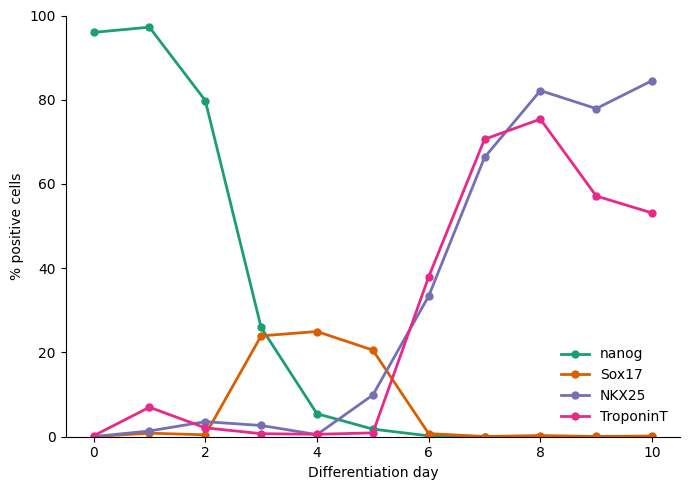

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

for clf, color in COLORS.items():
    d = summary_df[summary_df["classifier"] == clf]
    ax.plot(
        d["differentiation_day"],
        d["percent_positive"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=clf.replace("_classifier", ""),
        color=color,
    )

ax.set_xlabel("Differentiation day")
ax.set_ylabel("% positive cells")
ax.set_ylim(0, 100)

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

In [22]:
rows = []

for clf_col, pos_label in CLASSIFIERS.items():
    tmp = (
        df
        .assign(is_positive=lambda d: d[clf_col] == pos_label)
        .groupby(["differentiation_day", "well_name"])
        .agg(
            n_cells=("is_positive", "size"),
            n_positive=("is_positive", "sum"),
        )
        .reset_index()
    )

    tmp["percent_positive"] = 100 * tmp["n_positive"] / tmp["n_cells"]
    tmp["classifier"] = clf_col

    rows.append(tmp)

per_well_df = pd.concat(rows, ignore_index=True)

In [23]:
summary_df = (
    per_well_df
    .groupby(["differentiation_day", "classifier"])
    .agg(
        mean_percent=("percent_positive", "mean"),
        n_wells=("percent_positive", "size"),
        std_percent=("percent_positive", "std"),
    )
    .reset_index()
)
summary_df

,differentiation_day,classifier,mean_percent,n_wells,std_percent
0,0,NKX25_classifier,0.027331,4,0.010176
1,0,Sox17_classifier,0.027115,4,0.012660
2,0,TroponinT_classifier,0.209123,4,0.056782
3,0,nanog_classifier,95.785115,4,4.545775
4,1,NKX25_classifier,1.464545,2,1.283064
5,1,Sox17_classifier,0.802490,2,0.508209
6,1,TroponinT_classifier,6.927309,2,0.921676
7,1,nanog_classifier,97.114664,2,1.434324
8,2,NKX25_classifier,3.411980,2,0.931829
9,2,Sox17_classifier,0.553921,2,0.635365


In [24]:
from pathlib import Path

def savefig_both(fig, outbase, dpi_png=300, dpi_pdf=600):
    """
    Save a matplotlib figure as both PNG and PDF.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        The figure to save.
    outbase : str or Path
        Path without suffix, e.g. "figs/percent_positive_over_time"
    dpi_png : int
        DPI for PNG (300–600 typical)
    dpi_pdf : int
        DPI for rasterized artists in PDF (600–1200 typical)
    """
    outbase = Path(outbase)
    outbase.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(outbase.with_suffix(".png"), dpi=dpi_png, bbox_inches="tight")
    fig.savefig(outbase.with_suffix(".pdf"), dpi=dpi_pdf, bbox_inches="tight")

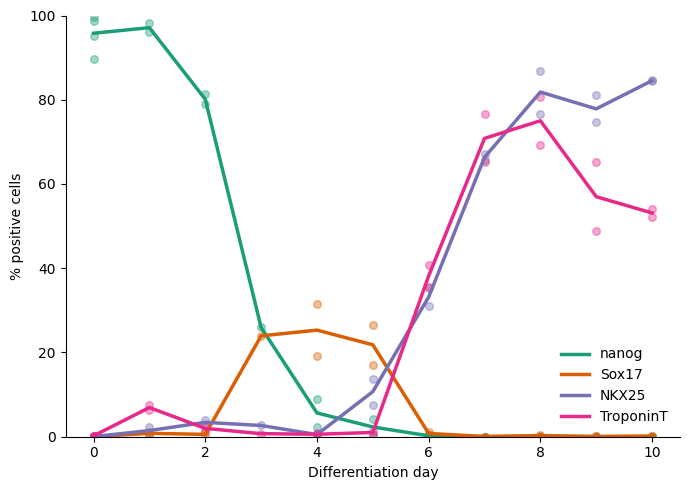

In [25]:
COLORS = {
    "nanog_classifier": "#1b9e77",
    "Sox17_classifier": "#d95f02",
    "NKX25_classifier": "#7570b3",
    "TroponinT_classifier": "#e7298a",
}

fig, ax = plt.subplots(figsize=(7, 5))

for clf, color in COLORS.items():
    # individual wells
    d_rep = per_well_df[per_well_df["classifier"] == clf]
    ax.scatter(
        d_rep["differentiation_day"],
        d_rep["percent_positive"],
        color=color,
        alpha=0.4,
        s=30,
    )

    # mean line
    d_mean = summary_df[summary_df["classifier"] == clf]
    ax.plot(
        d_mean["differentiation_day"],
        d_mean["mean_percent"],
        color=color,
        linewidth=2.5,
        label=clf.replace("_classifier", ""),
    )

ax.set_xlabel("Differentiation day")
ax.set_ylabel("% positive cells")
ax.set_ylim(0, 100)

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

fig.tight_layout()

savefig_both(fig, "figs/percent_positive_over_time")

# Hyperparameter tuning

In [ ]:
# For testing purposes, work on a subset of the data
df_sub = df.sample(n=100_000, random_state=0)
del df
exclude_cols = [
    "well_name", "ROI",
    "nanog_classifier", "Sox17_classifier",
    "NKX25_classifier", "TroponinT_classifier",
    "differentiation_day",
]

X_scaled = StandardScaler().fit_transform(df_sub.drop(columns=exclude_cols))
pca = PCA(n_components=50, random_state=0)
X_pca = pca.fit_transform(X_scaled)
n_neighbors = 30  # test 10 - 100
min_dist = 0.05 # test 0.01 - 0.3
random_state=42

In [ ]:
reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=2,
    metric="euclidean",
    # random_state=random_state,
)
embedding = reducer.fit_transform(X_pca)

In [ ]:
df_sub = df_sub.copy()
df_sub["UMAP1"] = embedding[:, 0]
df_sub["UMAP2"] = embedding[:, 1]

In [11]:
def umap_scatter_continuous(df_plot, c, title=None, s=2, alpha=0.6, cmap="viridis",
                           vmin=None, vmax=None, log_color=False):
    x = df_plot["UMAP1"].to_numpy()
    y = df_plot["UMAP2"].to_numpy()
    vals = df_plot[c].to_numpy()

    if log_color:
        vals = np.log1p(vals)

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(x, y, c=vals, s=s, alpha=alpha, linewidths=0,
                     cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title(title or f"UMAP colored by {c}")
    cb = plt.colorbar(sc)
    cb.set_label(f"{c}" + (" (log1p)" if log_color else ""))
    plt.tight_layout()
    plt.show()


def umap_scatter_categorical(df_plot, cat, title=None, s=2, alpha=0.6, max_categories=30):
    x = df_plot["UMAP1"].to_numpy()
    y = df_plot["UMAP2"].to_numpy()
    cats = df_plot[cat].astype("category")

    # Keep the legend sane
    if cats.nunique() > max_categories:
        # show top categories, rest -> "Other"
        top = cats.value_counts().index[:max_categories]
        cats = cats.where(cats.isin(top), other="Other").astype("category")

    plt.figure(figsize=(7, 6))
    for k in cats.cat.categories:
        m = (cats == k).to_numpy()
        plt.scatter(x[m], y[m], s=s, alpha=alpha, linewidths=0, label=str(k), rasterized=True)

    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title(title or f"UMAP colored by {cat}")
    plt.legend(markerscale=4, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

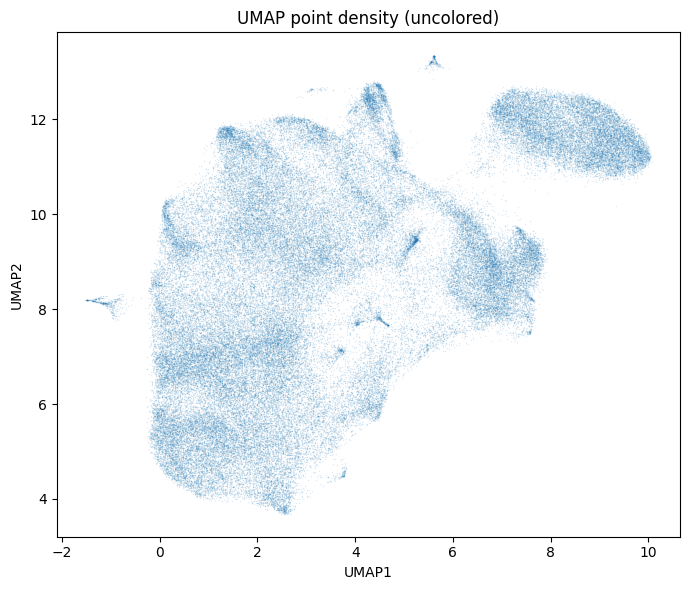

In [40]:
plt.figure(figsize=(7,6))
plt.scatter(df_sub["UMAP1"], df_sub["UMAP2"], s=1, alpha=0.15, linewidths=0, rasterized=True)
plt.xlabel("UMAP1"); plt.ylabel("UMAP2"); plt.title("UMAP point density (uncolored)")
plt.tight_layout(); plt.show()

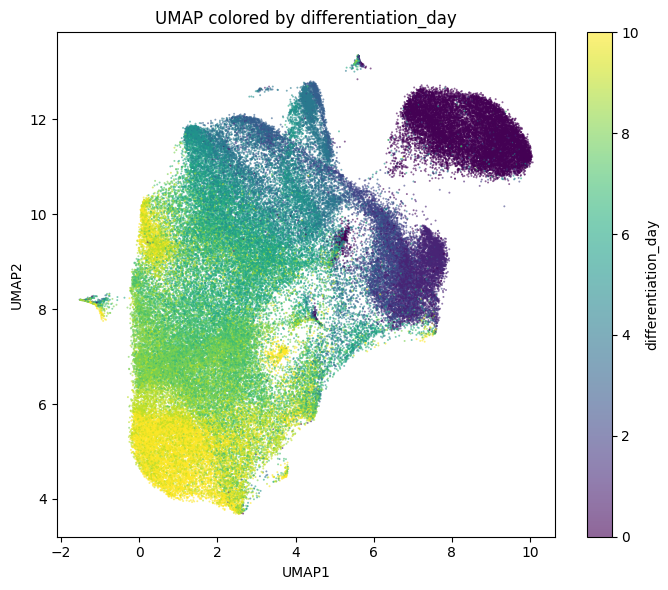

In [41]:
# umap_scatter_categorical(df_sub, "differentiation_day", max_categories=20)
umap_scatter_continuous(df_sub, "differentiation_day", cmap="viridis")

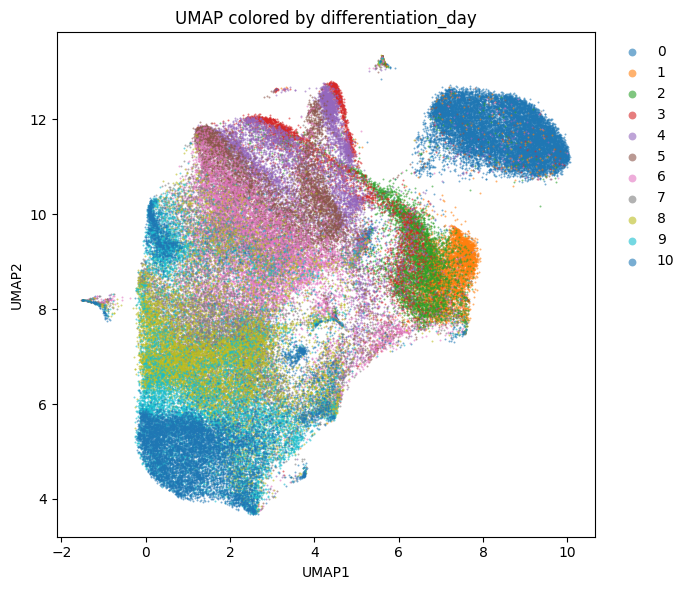

In [42]:
umap_scatter_categorical(df_sub, "differentiation_day", max_categories=20)

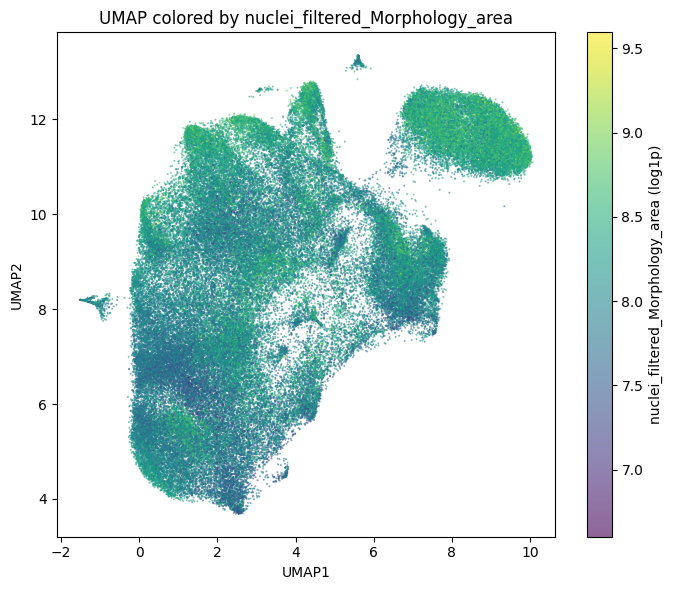

In [43]:
area_col = 'nuclei_filtered_Morphology_area'
umap_scatter_continuous(df_sub, area_col, log_color=True, cmap="viridis")

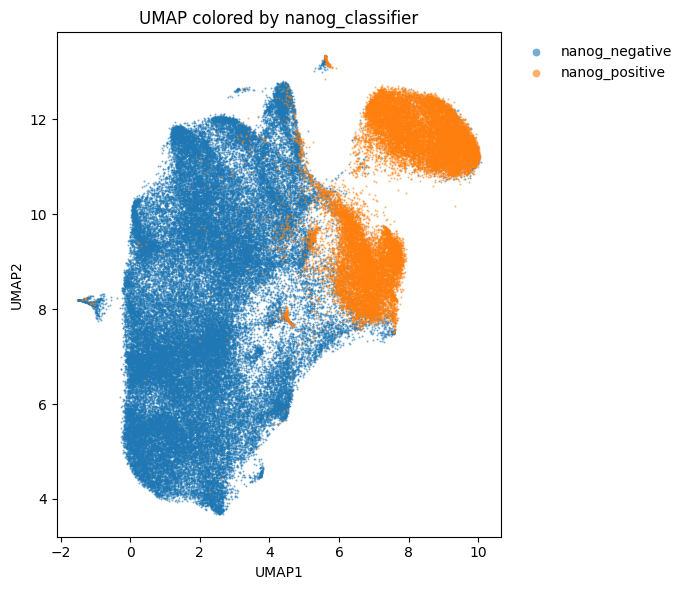

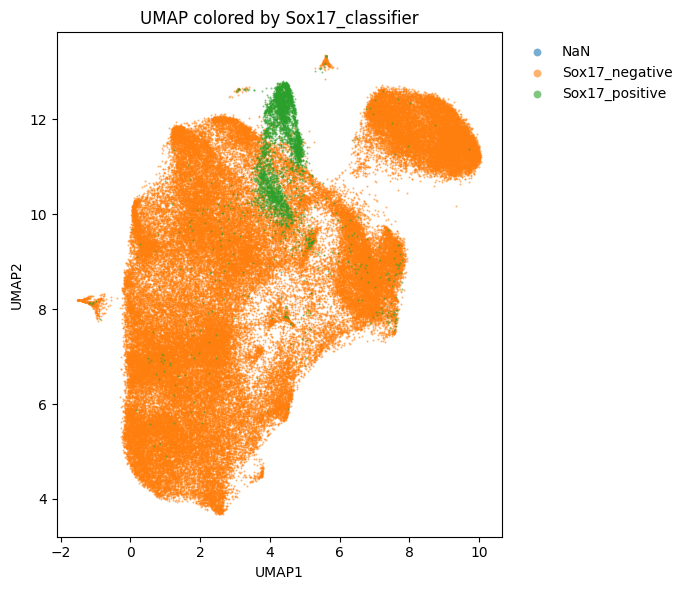

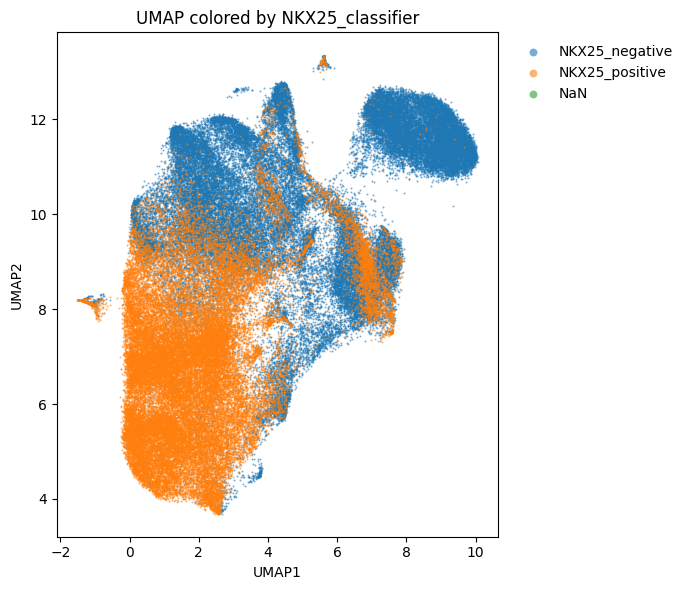

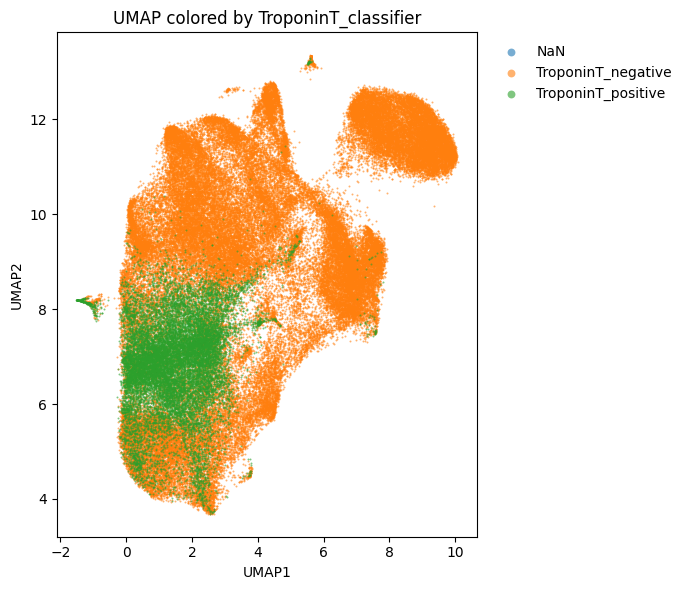

In [44]:
umap_scatter_categorical(df_sub, "nanog_classifier")
umap_scatter_categorical(df_sub, "Sox17_classifier")
umap_scatter_categorical(df_sub, "NKX25_classifier")
umap_scatter_categorical(df_sub, "TroponinT_classifier")

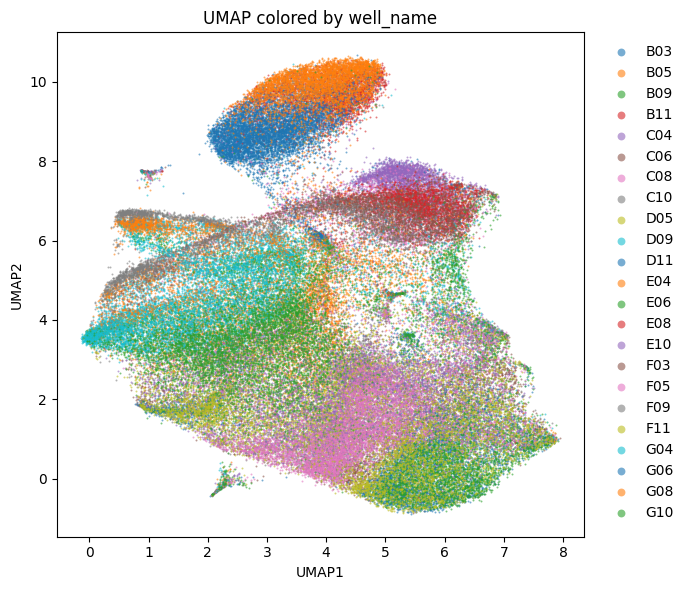

In [20]:
umap_scatter_categorical(df_sub, "well_name")
# umap_scatter_categorical(df_sub, "ROI")

In [28]:
df_sub["nanog_classifier"] = (
    df_sub["nanog_classifier"]
    .cat.remove_unused_categories()
)

col = "nanog_classifier"
vals = df_sub[col]

print(vals.dtype)
print(vals.unique())

# Catch common fake-nan strings
fake_nan = vals.astype(str).str.strip().str.lower().isin(["nan", "none", "null", ""])
print("fake-nan count:", fake_nan.sum())
print("examples:", vals[fake_nan].head())

category
['nanog_negative', 'nanog_positive']
Categories (2, object): ['nanog_negative', 'nanog_positive']
fake-nan count: 0
examples: Series([], Name: nanog_classifier, dtype: category
Categories (2, object): ['nanog_negative', 'nanog_positive'])


In [13]:
## Figuring out what the outlier group in the UMAP is
print(df.columns)

Index(['nuclei_filtered_Morphology_area',
       'nuclei_filtered_Morphology_centroid-0',
       'nuclei_filtered_Morphology_centroid-1',
       'nuclei_filtered_Morphology_well_centroid-0',
       'nuclei_filtered_Morphology_well_centroid-1',
       'nuclei_filtered_Morphology_bbox_area',
       'nuclei_filtered_Morphology_bbox-0',
       'nuclei_filtered_Morphology_bbox-1',
       'nuclei_filtered_Morphology_bbox-2',
       'nuclei_filtered_Morphology_bbox-3',
       ...
       'nuclei_filtered_Population_mean_distance_neighbours_radius_500',
       'well_name', 'ROI', 'nanog_classifier', 'Sox17_classifier',
       'NKX25_classifier', 'TroponinT_classifier', 'differentiation_day',
       'UMAP1', 'UMAP2'],
      dtype='object', length=2697)


(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'UMAP colored by nuclei_filtered_Morphology_bbox_area'}, xlabel='UMAP1', ylabel='UMAP2'>)

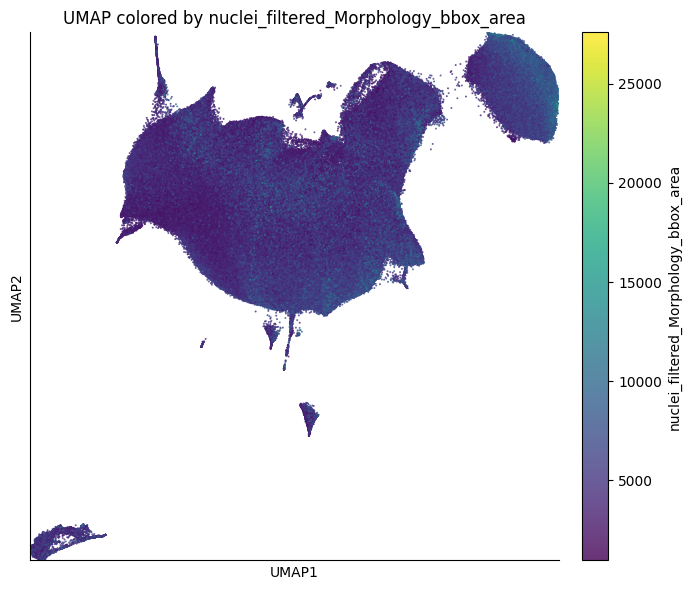

In [9]:
feature_col = 'nuclei_filtered_Morphology_bbox_area'
umap_continuous_figure(df, feature_col,
                       outbase=f"figs/umap_{feature_col}",
                       title=f"UMAP colored by {feature_col}",
                       cmap="viridis")

In [ ]:
# TODO: Select UMAP range from dataframe, check out FOV & well => what are outlier regions? Bottom & top

In [ ]:
min(df['UMAP2'])

-1.5203502178192139

In [ ]:
max(df['UMAP2'])

16.57730484008789

In [4]:
df_subset = df[df['UMAP2'] < 0.8]

In [14]:
df_subset = df_subset[df_subset["UMAP1"]> 2]

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'UMAP colored by nuclei_filtered_Morphology_bbox_area'}, xlabel='UMAP1', ylabel='UMAP2'>)

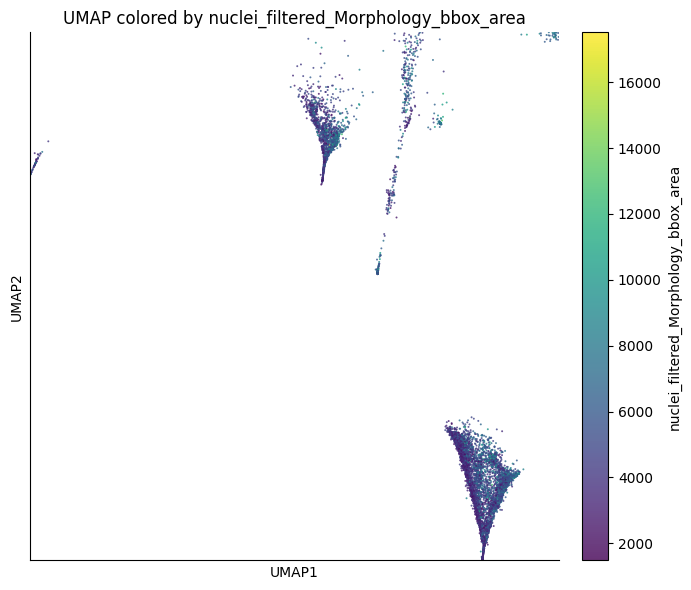

In [15]:
feature_col = 'nuclei_filtered_Morphology_bbox_area'
umap_continuous_figure(df_plot=df_subset, value_col=feature_col,
                       outbase=f"figs/umap_{feature_col}",
                       title=f"UMAP colored by {feature_col}",
                       cmap="viridis")

In [16]:
# Select numeric columns only
num1 = df.select_dtypes(include="number")
num2 = df_subset.select_dtypes(include="number")

# Compute means
mean1 = num1.mean()
mean2 = num2.mean()

# Compare
comparison = pd.DataFrame({
    "mean_df1": mean1,
    "mean_df2": mean2,
    "difference": mean2 - mean1,
    "relative_difference": (mean2 - mean1) / mean1
})

print(comparison)

                                                        mean_df1  \
nuclei_filtered_Morphology_area                      3518.251041   
nuclei_filtered_Morphology_centroid-0                1074.208635   
nuclei_filtered_Morphology_centroid-1                1280.774117   
nuclei_filtered_Morphology_well_centroid-0           9353.225491   
nuclei_filtered_Morphology_well_centroid-1          10289.751013   
...                                                          ...   
nuclei_filtered_Population_n_neighbours_radius_500    122.599246   
nuclei_filtered_Population_mean_distance_neighb...    319.741691   
differentiation_day                                     5.265500   
UMAP1                                                   8.139123   
UMAP2                                                   4.947747   

                                                        mean_df2  difference  \
nuclei_filtered_Morphology_area                      3486.723789  -31.527252   
nuclei_filtered_Morphol

In [17]:
comparison.to_csv("umap_outlier_comparison.csv")

In [ ]:
# What to exclude:
# DAPI 9-13, bTubulin, HSP60, bActin, PCNA, ABCD3, GM130

# Yap, EEA1

# Individual features:
nuclei_filtered_Intensity_min_intensity_N-Cadherin
nuclei_filtered_Intensity_min_intensity_Connexin-43

### Or get rid of individual cells:
nuclei_filtered_Intensity_min_intensity_HSP60 < 1
nuclei_filtered_Intensity_mean_intensity_DAPI_13 < 20
nuclei_filtered_Intensity_mean_intensity_DAPI_12 < 20

In [19]:
df

,nuclei_filtered_Morphology_area,nuclei_filtered_Morphology_centroid-0,nuclei_filtered_Morphology_centroid-1,nuclei_filtered_Morphology_well_centroid-0,nuclei_filtered_Morphology_well_centroid-1,nuclei_filtered_Morphology_bbox_area,nuclei_filtered_Morphology_bbox-0,nuclei_filtered_Morphology_bbox-1,nuclei_filtered_Morphology_bbox-2,nuclei_filtered_Morphology_bbox-3,...,nuclei_filtered_Population_mean_distance_neighbours_radius_500,well_name,ROI,nanog_classifier,Sox17_classifier,NKX25_classifier,TroponinT_classifier,differentiation_day,UMAP1,UMAP2
label,,,,,,,,,,,,,,,,,,,,,
44038,990.0,462.195953,1341.654541,11262.196289,11581.654297,1419.0,445.0,1321.0,478.0,1364.0,...,341.091156,C10,FOV_45,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,8,5.482522,6.650515
34104,3240.0,1863.642944,262.153076,10503.642578,18182.152344,4158.0,1831.0,231.0,1897.0,294.0,...,316.812622,E06,FOV_40,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,10,2.026527,5.877949
60910,3329.0,221.385406,1339.604980,15341.385742,16699.605469,4950.0,189.0,1304.0,255.0,1379.0,...,330.548431,E10,FOV_63,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_negative,7,4.997629,4.194227
13043,5217.0,125.632935,1551.744873,4444.632812,6671.744629,7470.0,85.0,1507.0,168.0,1597.0,...,309.306061,C04,FOV_19,nanog_positive,Sox17_negative,NKX25_negative,TroponinT_negative,1,12.055840,7.616817
72345,4107.0,2030.428345,952.072083,19310.427734,18872.072266,6561.0,1994.0,911.0,2075.0,992.0,...,335.096039,C10,FOV_72,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,8,6.502778,4.704004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48634,2310.0,1344.722900,2048.647949,14304.722656,19968.648438,3696.0,1310.0,2020.0,1376.0,2076.0,...,324.042847,C06,FOV_56,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,9,2.286838,4.194993
9775,3129.0,386.089172,1131.347412,2546.089111,8811.347656,4312.0,351.0,1101.0,428.0,1157.0,...,341.753601,F11,FOV_12,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,9,3.270163,5.701845
56022,1985.0,820.179871,380.764740,18100.179688,2940.764648,2610.0,798.0,352.0,843.0,410.0,...,305.611816,D11,FOV_66,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_positive,10,2.792006,5.578685


In [ ]:
df[df['nuclei_filtered_Texture_Haralick-Range-sum-of-squares-5_nanog'] < 20]

,nuclei_filtered_Morphology_area,nuclei_filtered_Morphology_centroid-0,nuclei_filtered_Morphology_centroid-1,nuclei_filtered_Morphology_well_centroid-0,nuclei_filtered_Morphology_well_centroid-1,nuclei_filtered_Morphology_bbox_area,nuclei_filtered_Morphology_bbox-0,nuclei_filtered_Morphology_bbox-1,nuclei_filtered_Morphology_bbox-2,nuclei_filtered_Morphology_bbox-3,...,nuclei_filtered_Population_mean_distance_neighbours_radius_500,well_name,ROI,nanog_classifier,Sox17_classifier,NKX25_classifier,TroponinT_classifier,differentiation_day,UMAP1,UMAP2
label,,,,,,,,,,,,,,,,,,,,,
44038,990.0,462.195953,1341.654541,11262.196289,11581.654297,1419.0,445.0,1321.0,478.0,1364.0,...,341.091156,C10,FOV_45,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,8,5.482522,6.650515
34104,3240.0,1863.642944,262.153076,10503.642578,18182.152344,4158.0,1831.0,231.0,1897.0,294.0,...,316.812622,E06,FOV_40,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,10,2.026527,5.877949
60910,3329.0,221.385406,1339.604980,15341.385742,16699.605469,4950.0,189.0,1304.0,255.0,1379.0,...,330.548431,E10,FOV_63,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_negative,7,4.997629,4.194227
13043,5217.0,125.632935,1551.744873,4444.632812,6671.744629,7470.0,85.0,1507.0,168.0,1597.0,...,309.306061,C04,FOV_19,nanog_positive,Sox17_negative,NKX25_negative,TroponinT_negative,1,12.055840,7.616817
72345,4107.0,2030.428345,952.072083,19310.427734,18872.072266,6561.0,1994.0,911.0,2075.0,992.0,...,335.096039,C10,FOV_72,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,8,6.502778,4.704004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48634,2310.0,1344.722900,2048.647949,14304.722656,19968.648438,3696.0,1310.0,2020.0,1376.0,2076.0,...,324.042847,C06,FOV_56,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,9,2.286838,4.194993
9775,3129.0,386.089172,1131.347412,2546.089111,8811.347656,4312.0,351.0,1101.0,428.0,1157.0,...,341.753601,F11,FOV_12,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,9,3.270163,5.701845
56022,1985.0,820.179871,380.764740,18100.179688,2940.764648,2610.0,798.0,352.0,843.0,410.0,...,305.611816,D11,FOV_66,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_positive,10,2.792006,5.578685


In [21]:
df[df['nuclei_filtered_Texture_Haralick-Range-contrast-5_nanog'] > 50]

,nuclei_filtered_Morphology_area,nuclei_filtered_Morphology_centroid-0,nuclei_filtered_Morphology_centroid-1,nuclei_filtered_Morphology_well_centroid-0,nuclei_filtered_Morphology_well_centroid-1,nuclei_filtered_Morphology_bbox_area,nuclei_filtered_Morphology_bbox-0,nuclei_filtered_Morphology_bbox-1,nuclei_filtered_Morphology_bbox-2,nuclei_filtered_Morphology_bbox-3,...,nuclei_filtered_Population_mean_distance_neighbours_radius_500,well_name,ROI,nanog_classifier,Sox17_classifier,NKX25_classifier,TroponinT_classifier,differentiation_day,UMAP1,UMAP2
label,,,,,,,,,,,,,,,,,,,,,
3958,2918.0,2010.062744,703.295410,2010.062744,13503.294922,4368.0,1967.0,674.0,2045.0,730.0,...,288.856445,D09,FOV_6,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,4,9.604618,2.977810
14811,1912.0,1912.599854,631.761536,4072.599854,5751.761719,2993.0,1881.0,613.0,1954.0,654.0,...,314.430237,G10,FOV_11,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,6,7.622886,3.830482
9295,2793.0,384.952728,1336.014282,2544.952637,6456.014160,3920.0,355.0,1300.0,411.0,1370.0,...,314.212250,G10,FOV_11,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_positive,6,7.038760,3.012035
50966,1892.0,1873.906494,946.793884,16993.906250,8626.793945,2684.0,1852.0,915.0,1896.0,976.0,...,306.193878,G04,FOV_60,nanog_negative,Sox17_positive,NKX25_positive,TroponinT_negative,5,6.756624,-0.148963
23667,2996.0,1827.417236,169.331116,6146.416992,15529.331055,4104.0,1797.0,134.0,1854.0,206.0,...,292.789948,B05,FOV_23,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_positive,6,6.892116,4.198799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34731,2334.0,1618.062988,2194.517578,8098.062988,2194.517578,3770.0,1586.0,2165.0,1651.0,2223.0,...,323.415955,F05,FOV_25,nanog_positive,Sox17_negative,NKX25_positive,TroponinT_positive,8,5.685322,4.698342
35764,3688.0,1922.837891,1839.981079,10562.837891,12079.981445,5456.0,1880.0,1810.0,1968.0,1872.0,...,294.160431,D11,FOV_37,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_negative,10,6.665279,0.203494
19439,4121.0,962.725769,1628.664917,5281.725586,16988.664062,5467.0,929.0,1590.0,1000.0,1667.0,...,326.391052,G10,FOV_23,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_positive,6,-1.361357,-6.887587


In [22]:
df[df['nuclei_filtered_Texture_Haralick-Range-angular-second-moment-5_DAPI_8'] > 0.02]


,nuclei_filtered_Morphology_area,nuclei_filtered_Morphology_centroid-0,nuclei_filtered_Morphology_centroid-1,nuclei_filtered_Morphology_well_centroid-0,nuclei_filtered_Morphology_well_centroid-1,nuclei_filtered_Morphology_bbox_area,nuclei_filtered_Morphology_bbox-0,nuclei_filtered_Morphology_bbox-1,nuclei_filtered_Morphology_bbox-2,nuclei_filtered_Morphology_bbox-3,...,nuclei_filtered_Population_mean_distance_neighbours_radius_500,well_name,ROI,nanog_classifier,Sox17_classifier,NKX25_classifier,TroponinT_classifier,differentiation_day,UMAP1,UMAP2
label,,,,,,,,,,,,,,,,,,,,,
9567,2572.0,414.286163,2467.858887,4733.286133,7587.858887,4187.0,374.0,2441.0,453.0,2494.0,...,309.192261,E04,FOV_19,nanog_negative,Sox17_positive,NKX25_negative,TroponinT_negative,4,8.067711,-2.884732
48766,3582.0,1414.588257,2470.642578,14374.587891,17830.642578,4648.0,1374.0,2442.0,1457.0,2498.0,...,339.671143,C06,FOV_55,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,9,8.008030,-2.433139
38166,3354.0,1255.088867,2469.168701,9895.088867,10149.168945,4440.0,1218.0,2440.0,1292.0,2500.0,...,321.339935,C10,FOV_36,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,8,7.839739,-2.246321
43879,3386.0,470.985535,330.951263,11270.985352,18250.951172,4386.0,428.0,306.0,514.0,357.0,...,337.396545,G10,FOV_48,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,6,-0.971559,-7.076759
25019,2649.0,228.026428,2466.856445,8868.026367,10146.856445,3795.0,194.0,2441.0,263.0,2496.0,...,283.532074,C04,FOV_36,nanog_positive,Sox17_negative,NKX25_negative,TroponinT_negative,1,8.063856,-2.981442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2834,3950.0,794.820496,2471.836426,794.820496,20391.835938,6336.0,744.0,2437.0,840.0,2503.0,...,314.285614,E08,FOV_8,nanog_positive,Sox17_negative,NKX25_negative,TroponinT_negative,1,8.216851,-2.522030
2793,2124.0,852.297546,2475.460449,852.297546,7595.460449,3264.0,832.0,2437.0,880.0,2505.0,...,306.568176,G04,FOV_3,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,5,8.038952,-2.998095
5148,3110.0,1458.878174,2460.322266,1458.878174,12700.322266,4200.0,1429.0,2426.0,1489.0,2496.0,...,317.201324,E08,FOV_5,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,1,10.850820,8.379356


In [ ]:
df[df['nuclei_filtered_Texture_Haralick-Range-contrast-5_nanog'] > 50]

In [31]:
df[df['nuclei_filtered_Intensity_mean_intensity_DAPI_12'] < 30]

,nuclei_filtered_Morphology_area,nuclei_filtered_Morphology_centroid-0,nuclei_filtered_Morphology_centroid-1,nuclei_filtered_Morphology_well_centroid-0,nuclei_filtered_Morphology_well_centroid-1,nuclei_filtered_Morphology_bbox_area,nuclei_filtered_Morphology_bbox-0,nuclei_filtered_Morphology_bbox-1,nuclei_filtered_Morphology_bbox-2,nuclei_filtered_Morphology_bbox-3,...,nuclei_filtered_Population_mean_distance_neighbours_radius_500,well_name,ROI,nanog_classifier,Sox17_classifier,NKX25_classifier,TroponinT_classifier,differentiation_day,UMAP1,UMAP2
label,,,,,,,,,,,,,,,,,,,,,
15511,3501.0,1723.141968,733.987732,3883.141846,16093.987305,4608.0,1687.0,701.0,1759.0,765.0,...,340.474762,B05,FOV_15,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_positive,6,0.142983,-6.403520
15617,3395.0,1751.172852,992.429443,3911.172852,13792.429688,4650.0,1716.0,962.0,1791.0,1024.0,...,343.192871,B05,FOV_14,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,6,-1.058769,-6.980016
23077,3836.0,1157.897339,980.619141,5476.897461,18900.619141,5609.0,1127.0,938.0,1198.0,1017.0,...,340.528595,E10,FOV_24,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,7,-0.075845,-6.280752
53716,3183.0,745.635254,670.758118,15865.634766,3230.758057,5832.0,713.0,631.0,794.0,703.0,...,297.303741,B05,FOV_58,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,6,1.686687,3.387729
32978,1798.0,998.729675,357.401550,9638.729492,357.401550,2835.0,954.0,342.0,1035.0,377.0,...,327.206421,D11,FOV_33,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,10,1.790527,3.394810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39071,1532.0,1327.445801,1976.879883,9967.446289,19896.880859,2585.0,1302.0,1947.0,1349.0,2002.0,...,340.919647,G10,FOV_40,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,6,-1.279786,-7.039241
45036,3228.0,2070.865967,1657.252808,12870.866211,19577.251953,4176.0,2047.0,1614.0,2095.0,1701.0,...,340.928040,B05,FOV_48,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,6,0.193503,-6.321409
16214,3143.0,1899.735962,1377.249756,4059.735840,14177.250000,4898.0,1872.0,1335.0,1934.0,1414.0,...,315.901855,B05,FOV_14,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,6,-1.109751,-6.908995


In [ ]:
df = df[df['nuclei_filtered_Texture_Haralick-Mean-angular-second-moment-5_bTubulin'] > 0.4]

,nuclei_filtered_Morphology_area,nuclei_filtered_Morphology_centroid-0,nuclei_filtered_Morphology_centroid-1,nuclei_filtered_Morphology_well_centroid-0,nuclei_filtered_Morphology_well_centroid-1,nuclei_filtered_Morphology_bbox_area,nuclei_filtered_Morphology_bbox-0,nuclei_filtered_Morphology_bbox-1,nuclei_filtered_Morphology_bbox-2,nuclei_filtered_Morphology_bbox-3,...,nuclei_filtered_Population_mean_distance_neighbours_radius_500,well_name,ROI,nanog_classifier,Sox17_classifier,NKX25_classifier,TroponinT_classifier,differentiation_day,UMAP1,UMAP2
label,,,,,,,,,,,,,,,,,,,,,
15617,3395.0,1751.172852,992.429443,3911.172852,13792.429688,4650.0,1716.0,962.0,1791.0,1024.0,...,343.192871,B05,FOV_14,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,6,-1.058769,-6.980016
43879,3386.0,470.985535,330.951263,11270.985352,18250.951172,4386.0,428.0,306.0,514.0,357.0,...,337.396545,G10,FOV_48,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,6,-0.971559,-7.076759
22968,2380.0,1802.388184,2053.788574,6121.388184,17413.789062,2832.0,1778.0,2025.0,1826.0,2084.0,...,327.306122,G10,FOV_23,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_positive,6,-1.263294,-6.973171
31885,2095.0,1760.835327,99.831505,8240.834961,18019.832031,4440.0,1733.0,63.0,1807.0,123.0,...,305.861511,G10,FOV_32,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_negative,6,-1.205469,-7.037544
9140,2319.0,100.769730,2092.532227,2260.769775,14892.532227,3172.0,73.0,2064.0,125.0,2125.0,...,281.493164,B05,FOV_14,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,6,0.116434,-6.390570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39071,1532.0,1327.445801,1976.879883,9967.446289,19896.880859,2585.0,1302.0,1947.0,1349.0,2002.0,...,340.919647,G10,FOV_40,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,6,-1.279786,-7.039241
16214,3143.0,1899.735962,1377.249756,4059.735840,14177.250000,4898.0,1872.0,1335.0,1934.0,1414.0,...,315.901855,B05,FOV_14,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,6,-1.109751,-6.908995
17584,2912.0,108.299797,448.251709,4427.299805,13248.251953,4125.0,72.0,421.0,147.0,476.0,...,345.981201,B05,FOV_22,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,6,-0.924832,-6.416114


In [27]:
df

,nuclei_filtered_Morphology_area,nuclei_filtered_Morphology_centroid-0,nuclei_filtered_Morphology_centroid-1,nuclei_filtered_Morphology_well_centroid-0,nuclei_filtered_Morphology_well_centroid-1,nuclei_filtered_Morphology_bbox_area,nuclei_filtered_Morphology_bbox-0,nuclei_filtered_Morphology_bbox-1,nuclei_filtered_Morphology_bbox-2,nuclei_filtered_Morphology_bbox-3,...,nuclei_filtered_Population_mean_distance_neighbours_radius_500,well_name,ROI,nanog_classifier,Sox17_classifier,NKX25_classifier,TroponinT_classifier,differentiation_day,UMAP1,UMAP2
label,,,,,,,,,,,,,,,,,,,,,
44038,990.0,462.195953,1341.654541,11262.196289,11581.654297,1419.0,445.0,1321.0,478.0,1364.0,...,341.091156,C10,FOV_45,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,8,5.482522,6.650515
34104,3240.0,1863.642944,262.153076,10503.642578,18182.152344,4158.0,1831.0,231.0,1897.0,294.0,...,316.812622,E06,FOV_40,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,10,2.026527,5.877949
60910,3329.0,221.385406,1339.604980,15341.385742,16699.605469,4950.0,189.0,1304.0,255.0,1379.0,...,330.548431,E10,FOV_63,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_negative,7,4.997629,4.194227
13043,5217.0,125.632935,1551.744873,4444.632812,6671.744629,7470.0,85.0,1507.0,168.0,1597.0,...,309.306061,C04,FOV_19,nanog_positive,Sox17_negative,NKX25_negative,TroponinT_negative,1,12.055840,7.616817
72345,4107.0,2030.428345,952.072083,19310.427734,18872.072266,6561.0,1994.0,911.0,2075.0,992.0,...,335.096039,C10,FOV_72,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,8,6.502778,4.704004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48634,2310.0,1344.722900,2048.647949,14304.722656,19968.648438,3696.0,1310.0,2020.0,1376.0,2076.0,...,324.042847,C06,FOV_56,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,9,2.286838,4.194993
9775,3129.0,386.089172,1131.347412,2546.089111,8811.347656,4312.0,351.0,1101.0,428.0,1157.0,...,341.753601,F11,FOV_12,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,9,3.270163,5.701845
56022,1985.0,820.179871,380.764740,18100.179688,2940.764648,2610.0,798.0,352.0,843.0,410.0,...,305.611816,D11,FOV_66,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_positive,10,2.792006,5.578685


In [20]:
df_subset

,nuclei_filtered_Morphology_area,nuclei_filtered_Morphology_centroid-0,nuclei_filtered_Morphology_centroid-1,nuclei_filtered_Morphology_well_centroid-0,nuclei_filtered_Morphology_well_centroid-1,nuclei_filtered_Morphology_bbox_area,nuclei_filtered_Morphology_bbox-0,nuclei_filtered_Morphology_bbox-1,nuclei_filtered_Morphology_bbox-2,nuclei_filtered_Morphology_bbox-3,...,nuclei_filtered_Population_mean_distance_neighbours_radius_500,well_name,ROI,nanog_classifier,Sox17_classifier,NKX25_classifier,TroponinT_classifier,differentiation_day,UMAP1,UMAP2
label,,,,,,,,,,,,,,,,,,,,,
9567,2572.0,414.286163,2467.858887,4733.286133,7587.858887,4187.0,374.0,2441.0,453.0,2494.0,...,309.192261,E04,FOV_19,nanog_negative,Sox17_positive,NKX25_negative,TroponinT_negative,4,8.067711,-2.884732
48766,3582.0,1414.588257,2470.642578,14374.587891,17830.642578,4648.0,1374.0,2442.0,1457.0,2498.0,...,339.671143,C06,FOV_55,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,9,8.008030,-2.433139
38166,3354.0,1255.088867,2469.168701,9895.088867,10149.168945,4440.0,1218.0,2440.0,1292.0,2500.0,...,321.339935,C10,FOV_36,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_positive,8,7.839739,-2.246321
25019,2649.0,228.026428,2466.856445,8868.026367,10146.856445,3795.0,194.0,2441.0,263.0,2496.0,...,283.532074,C04,FOV_36,nanog_positive,Sox17_negative,NKX25_negative,TroponinT_negative,1,8.063856,-2.981442
1243,3931.0,382.024414,2466.809570,382.024414,17826.808594,5609.0,346.0,2429.0,417.0,2508.0,...,300.876587,B03,FOV_7,nanog_positive,Sox17_negative,NKX25_negative,TroponinT_negative,0,8.173826,-2.653740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2793,2124.0,852.297546,2475.460449,852.297546,7595.460449,3264.0,832.0,2437.0,880.0,2505.0,...,306.568176,G04,FOV_3,nanog_negative,Sox17_negative,NKX25_negative,TroponinT_negative,5,8.038952,-2.998095
35764,3688.0,1922.837891,1839.981079,10562.837891,12079.981445,5456.0,1880.0,1810.0,1968.0,1872.0,...,294.160431,D11,FOV_37,nanog_negative,Sox17_negative,NKX25_positive,TroponinT_negative,10,6.665279,0.203494
7151,3124.0,1868.157471,848.095398,4028.157471,13648.095703,3886.0,1834.0,820.0,1901.0,878.0,...,326.717651,G06,FOV_14,nanog_positive,Sox17_negative,NKX25_negative,TroponinT_negative,0,6.747316,-0.211550
